<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/06-Function-Calling-%26-Data_Extraction/02_Variations_of_funcion_calling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install -q groq

from groq import Groq
from google.colab import userdata
import tiktoken

GROQ_API_KEY = userdata.get('groq_key')
client = Groq(api_key=GROQ_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 10.0 MB/s eta 0:00:00


In [21]:
def get_completion(prompt, model="llama-3.3-70b-versatile"):
  messages = [{'role':'system','content': "You are being used as a tool calling agent, just respond with the function call ONLY"},
              {"role": "user", "content": prompt}]
  response = client.chat.completions.create(
    model=model,
    messages=messages,
    temperature=0,)
  return response.choices[0].message.content

In [19]:
def get_completion_from_messages(messages, tools,
                                 model="llama-3.3-70b-versatile",
                                 temperature=0, ):
    response = client.chat.completions.create(
        model=model,
        tools=tools,
        messages=messages,
        temperature=temperature, # this is the degree of randomness of the model's output
    )
    return response.choices[0].message.tool_calls[0]

## House Keeping

In [2]:
def afunction(arg1: int = 0, arg2:str = "hello", **kwargs)->int:
  ''' this is a function definition
  arg1 (int): an exemplary yet modest argument
  arg2 (str): another nice argument
  **kwargs: the rest of the rabble
  returns arg1 incremented by one
  '''
  return(arg + 1)

In [3]:
print(afunction.__name__)
print(afunction.__doc__)

afunction
 this is a function definition
  arg1 (int): an exemplary yet modest argument
  arg2 (str): another nice argument
  **kwargs: the rest of the rabble
  returns arg1 incremented by one
  


we can use python inspect module too

In [4]:
import inspect
print(inspect.signature(afunction))

(arg1: int = 0, arg2: str = 'hello', **kwargs) -> int


In [10]:
def build_prompt(function_list, user_query):
  f_prompt = ""
  for function in function_list:
    signature = inspect.signature(function)
    docstring = function.__doc__
    prompt= f''' Function:
def {function.__name__}{signature}
  """
  {docstring.strip()}
  """
     '''
    f_prompt += prompt
  f_prompt+= f"User Query: {user_query}<human_end>"
  return f_prompt

In [11]:
print(build_prompt([afunction], "what is the meaning of life?"))

 Function:
def afunction(arg1: int = 0, arg2: str = 'hello', **kwargs) -> int
  """
  this is a function definition
  arg1 (int): an exemplary yet modest argument
  arg2 (str): another nice argument
  **kwargs: the rest of the rabble
  returns arg1 incremented by one
  """
     User Query: what is the meaning of life?<human_end>


## Parallel Calling of Function

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_clown_face(face_color='yellow', eye_color='black', nose_color='red',
                    eye_size=0.05, mouth_size=(0.2, 0.08), mouth_color='black',
                    eye_offset=(0.15, 0.15), mouth_theta=(200, 340)):
    """
    Draws a customizable, simplified clown face using matplotlib.

    This function creates a figure and an axes object, then adds various
    patches (circles and a wedge) to represent the features of a clown face.
    The face, eyes, and nose colors can be customized.

    Args:
        face_color (str, optional): The color of the clown's face. Defaults to 'yellow'.
        eye_color (str, optional): The color of the clown's eyes. Defaults to 'black'.
        nose_color (str, optional): The color of the clown's nose. Defaults to 'red'.
        eye_size (float, optional): The radius of the clown's eyes. Defaults to 0.05.
        mouth_size (tuple, optional): A tuple (radius, width) for the clown's mouth. Defaults to (0.2, 0.08).
        mouth_color (str, optional): The color of the clown's mouth. Defaults to 'black'.
        eye_offset (tuple, optional): A tuple (x_offset, y_offset) for the eyes from the center. Defaults to (0.15, 0.15).
        mouth_theta (tuple, optional): A tuple (start_angle, end_angle) for the mouth wedge and controls the emotions of the clown such as happy,sad. Defaults to (200, 340).
    """
    # Constants
    face_radius = 0.4
    nose_radius = 0.1
    nose_x, nose_y = 0.5, 0.5
    mouth_x, mouth_y = 0.5, 0.3

    fig, ax = plt.subplots()

    # Face
    face = patches.Circle((0.5, 0.5), face_radius, color=face_color, fill=True)
    ax.add_patch(face)

    # Eyes
    left_eye = patches.Circle((0.5 - eye_offset[0], 0.5 + eye_offset[1]), eye_size, color=eye_color)
    right_eye = patches.Circle((0.5 + eye_offset[0], 0.5 + eye_offset[1]), eye_size, color=eye_color)
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    # Nose
    nose = patches.Circle((nose_x, nose_y), nose_radius, color=nose_color)
    ax.add_patch(nose)

    # Mouth (Wedge used for a smile)
    mouth_center_y = mouth_y + 0.1 # Default center
    # Adjust mouth position if it's an upward-facing arc (frown) to make it look more natural
    if (mouth_theta[0] + mouth_theta[1]) / 2 < 180: # Heuristic for roughly upper half arc
        mouth_center_y -= mouth_size[0] * 0.2 # Move center down slightly for frown

    mouth = patches.Wedge((mouth_x, mouth_center_y), mouth_size[0], mouth_theta[0], mouth_theta[1], color=mouth_color, width=mouth_size[1])
    ax.add_patch(mouth)

    # Formatting
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

In [15]:
user_msg = f"""Hey, can you build me two clowns.
The first clown should be red faced, with a blue nose
and a mouth from 0 to 180 degrees. The mouth should be black.
The second clown should have a blue face and a green nose
and a red mouth that's 180 to 360 degrees."""

In [22]:
query= build_prompt([draw_clown_face], user_msg)
call= get_completion(query)
print(call)

draw_clown_face(face_color='red', nose_color='blue', mouth_theta=(0, 180), mouth_color='black')
draw_clown_face(face_color='blue', nose_color='green', mouth_theta=(180, 360), mouth_color='red')


In [23]:
type(call)

str

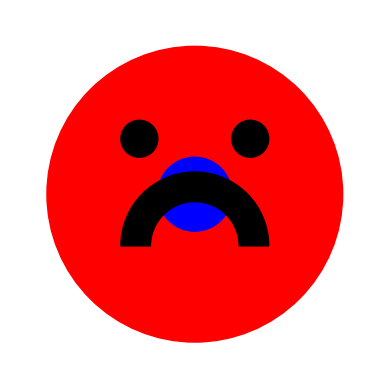

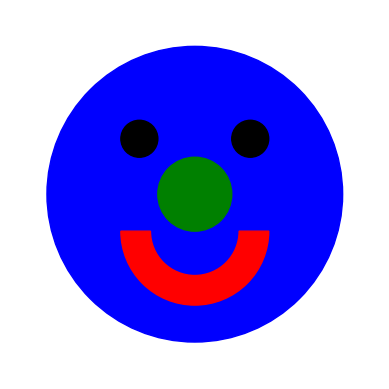

In [27]:
exec(call)

## Multiple Functions
provide the LLM with multiple functions and the LLM should be able to pick the right function

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_tie():
    """
    Draws a simplified black tie using matplotlib.

    This function creates a new matplotlib figure and axes, then draws
    two interconnected triangle patches to represent a stylized necktie.
    The tie is rendered in a solid black color.

    Args:
        None: This function does not accept any arguments.

    Returns:
        None: This function displays the plot directly and does not return any value.
    """
    plt.figure(figsize=(1, 2))
    ax = plt.gca()

    # Top triangle loop
    top_triangle_vertices = [(0.25, 0.75), (0.5, 1), (0, 1)]
    top_triangle_loop = patches.Polygon(top_triangle_vertices, closed=True, color='black')
    ax.add_patch(top_triangle_loop)

    # Tail triangle loop
    tail_triangle_vertices = [(0.25, 0.75), (0.5, 0), (0, 0)]
    tail_triangle_loop = patches.Polygon(tail_triangle_vertices, closed=True, color='black')
    ax.add_patch(tail_triangle_loop)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.set_aspect('equal')
    plt.axis('off')
    plt.show()

In [31]:
user_query= "Hey draw a tie?"

In [32]:
query= build_prompt([draw_clown_face,draw_tie], user_query)
call= get_completion(query)
print(call)

draw_tie()


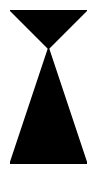

In [33]:
exec(call)

## Multiple Parallel Function Calling

In [36]:
user_query = "Draw a clown with pink face and a tie?"

In [38]:
query= build_prompt([draw_clown_face,draw_tie], user_query)
call= get_completion(query)
print(call)

draw_clown_face(face_color='pink'); draw_tie()


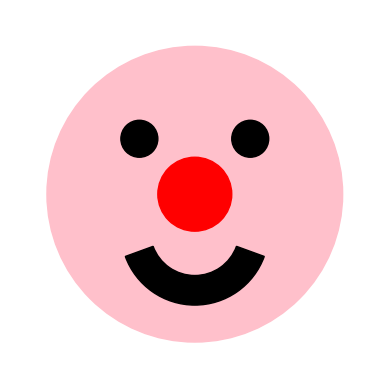

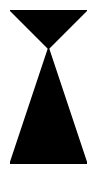

In [39]:
exec(call)

In [43]:
user_query = "Draw me a sad one with green head"
query= build_prompt([draw_clown_face,draw_tie], user_query)
call= get_completion(query)
print(call)

draw_clown_face(face_color='green', mouth_theta=(220, 320))


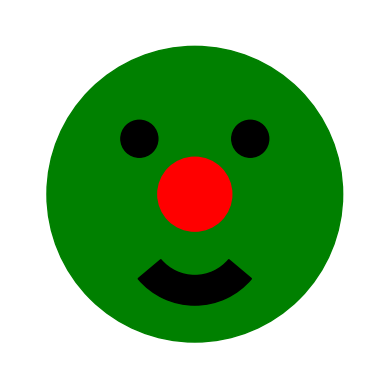

In [44]:
exec(call)

In [52]:
user_query = "Draw me a sad clown with green head"
query= build_prompt([draw_clown_face,draw_tie], user_query)
call= get_completion(query)
print(call)

draw_clown_face(face_color='green', eye_color='black', nose_color='red', eye_size=0.05, mouth_size=(0.2, 0.08), mouth_color='black', eye_offset=(0.15, 0.15), mouth_theta=(20, 160))


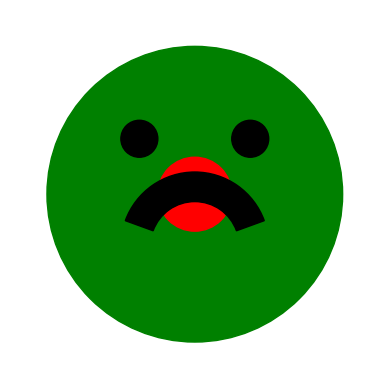

In [53]:
exec(call)